In [4]:
from tvm import te


In [5]:
A = te.placeholder((128, 128), name="A", dtype="float32")
B = te.placeholder((128, 128), name="B", dtype="float32")


In [6]:
type(A)

tvm.te.tensor.Tensor

In [7]:
A.shape

[128, 128]

In [8]:
def te_matmul(A: te.Tensor, B: te.Tensor) -> te.Tensor:
    assert A.shape[1] == B.shape[0]
    n = A.shape[0]
    m = B.shape[1]
    k = te.reduce_axis((0, A.shape[1]), name="k")
    return te.compute(
        (n, m), lambda i, j: te.sum(A[i, k] * B[k, j], axis=k), name="matmul"
    )


In [40]:
C = te_matmul(A, B)
type(C)

tvm.te.tensor.Tensor

In [42]:
te.create_prim_func([A, B, C]).show()


In [36]:
def te_relu(A: te.Tensor) -> te.Tensor:
    return te.compute(A.shape, lambda *i: te.max(A(*i), 0), name="relu")


In [37]:
X1 = te.placeholder((10,), name="X1", dtype="float32")
Y1 = te_relu(X1)
te.create_prim_func([X1, Y1]).show()


In [44]:
X2 = te.placeholder((10, 20), name="X1", dtype="float32")
Y2 = te_relu(X2)
te.create_prim_func([X2, Y2]).show()


In [45]:
C = te_matmul(A, B)
D = te_relu(C)


In [46]:
te.create_prim_func([A, B, D]).show()


In [47]:
te.create_prim_func([A, B, C, D]).show()


In [48]:
from tvm import relax

A = relax.Var("A", relax.TensorStructInfo((128, 128), "float32"))
B = relax.Var("B", relax.TensorStructInfo((128, 128), "float32"))


In [49]:
bb = relax.BlockBuilder()

with bb.function("main"):
    with bb.dataflow():
        C = bb.emit_te(te_matmul, A, B)
        D = bb.emit_te(te_relu, C)
        R = bb.emit_output(D)
    bb.emit_func_output(R, params=[A, B])

MyModule = bb.get()
MyModule.show()


In [50]:
type(C)


tvm.relax.expr.DataflowVar

In [51]:
isinstance(C, relax.Var)


True

### PyTorch


In [ ]:
import torch
import torch.nn as nn


class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.weight = nn.Parameter(torch.randn(128, 128))

    def forward(self, x):
        x = torch.matmul(x, self.weight)
        x = torch.relu(x)
        return x


In [53]:
import torch.fx as fx

model = MyModel()
fx_module = fx.symbolic_trace(model)
type(fx_module)


torch.fx.graph_module.GraphModule.__new__.<locals>.GraphModuleImpl

In [55]:
fx_module.graph.print_tabular()


opcode         name    target                                                     args         kwargs
-------------  ------  ---------------------------------------------------------  -----------  --------
placeholder    x       x                                                          ()           {}
get_attr       weight  weight                                                     ()           {}
call_function  matmul  <built-in method matmul of type object at 0x72809df29b40>  (x, weight)  {}
call_function  relu    <built-in method relu of type object at 0x72809df29b40>    (matmul,)    {}
output         output  output                                                     (relu,)      {}


In [56]:
def map_param(param: nn.Parameter):
    t = param.detach() if hasattr(param, "detach") else param
    arr = t.cpu().numpy().astype("float32")
    return relax.const(arr, "float32")


def fetch_attr(fx_mod, target: str):
    """Helper function to fetch an attr"""
    target_atoms = target.split(".")
    attr_itr = fx_mod
    for i, atom in enumerate(target_atoms):
        if not hasattr(attr_itr, atom):
            raise RuntimeError(
                f"Node referenced nonexistant target {'.'.join(target_atoms[:i])}"
            )
        attr_itr = getattr(attr_itr, atom)
    return attr_itr


def from_fx(fx_mod, input_shapes, call_function_map, call_module_map):
    input_index = 0
    node_map = {}
    named_modules = dict(fx_mod.named_modules())

    bb = relax.BlockBuilder()

    fn_inputs = []
    fn_output = None
    with bb.function("main"):
        with bb.dataflow():
            for node in fx_mod.graph.nodes:
                if node.op == "placeholder":
                    # create input placeholder
                    shape = input_shapes[input_index]
                    input_index += 1
                    input_var = relax.Var(
                        node.target, relax.TensorStructInfo(shape, "float32")
                    )
                    fn_inputs.append(input_var)
                    node_map[node] = input_var
                elif node.op == "get_attr":
                    node_map[node] = map_param(fetch_attr(fx_mod, node.target))
                elif node.op == "call_function":
                    node_map[node] = call_function_map[node.target](bb, node_map, node)
                elif node.op == "call_module":
                    named_module = named_modules[node.target]
                    node_map[node] = call_module_map[type(named_module)](
                        bb, node_map, node, named_module
                    )
                elif node.op == "output":
                    output = node_map[node.args[0]]
                    assert fn_output is None
                    fn_output = bb.emit_output(output)
        # output and finalize the function
        bb.emit_func_output(output, fn_inputs)
    return bb.get()


In [57]:
def map_matmul(bb, node_map, node: fx.Node):
    A = node_map[node.args[0]]
    B = node_map[node.args[1]]
    return bb.emit_te(te_matmul, A, B)


def map_relu(bb, node_map, node: fx.Node):
    A = node_map[node.args[0]]
    return bb.emit_te(te_relu, A)


MyModule = from_fx(
    fx_module,
    input_shapes=[(1, 128)],
    call_function_map={
        torch.matmul: map_matmul,
        torch.relu: map_relu,
    },
    call_module_map={},
)

MyModule.show()


In [58]:
import torch
import torchvision

test_data = torchvision.datasets.FashionMNIST(
    root="data", train=False, download=True, transform=torchvision.transforms.ToTensor()
)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=1, shuffle=True)
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

img, label = next(iter(test_loader))
img = img.reshape(1, 28, 28).numpy()


100.0%
100.0%
100.0%
100.0%


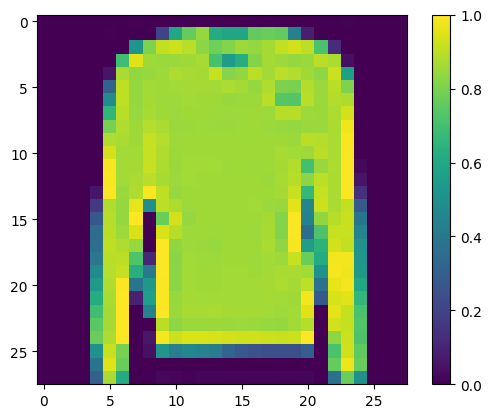

Class: Pullover


In [59]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(img[0])
plt.colorbar()
plt.grid(False)
plt.show()

print("Class:", class_names[label[0]])


In [60]:
# Hide outputs
!wget -nc https://github.com/mlc-ai/web-data/raw/main/models/fasionmnist_mlp_params.pkl


--2026-04-18 13:30:34--  https://github.com/mlc-ai/web-data/raw/main/models/fasionmnist_mlp_params.pkl
Loaded CA certificate '/etc/ssl/certs/ca-certificates.crt'
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mlc-ai/web-data/main/models/fasionmnist_mlp_params.pkl [following]
--2026-04-18 13:30:34--  https://raw.githubusercontent.com/mlc-ai/web-data/main/models/fasionmnist_mlp_params.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 407396 (398K) [application/octet-stream]
Saving to: 'fasionmnist_mlp_params.pkl'

fasionmnist_mlp_par 100%[===================>] 397.85K  1.61MB/s    in 0.2s    



In [61]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.linear0 = nn.Linear(784, 128, bias=True)
        self.relu = nn.ReLU()
        self.linear1 = nn.Linear(128, 10, bias=True)

    def forward(self, x):
        x = self.linear0(x)
        x = self.relu(x)
        x = self.linear1(x)
        return x


In [62]:
import pickle as pkl

mlp_model = MLP()

mlp_params = pkl.load(open("fasionmnist_mlp_params.pkl", "rb"))
mlp_model.linear0.weight.data = torch.from_numpy(mlp_params["w0"])
mlp_model.linear0.bias.data = torch.from_numpy(mlp_params["b0"])
mlp_model.linear1.weight.data = torch.from_numpy(mlp_params["w1"])
mlp_model.linear1.bias.data = torch.from_numpy(mlp_params["b1"])


In [63]:
import numpy as np

torch_res = mlp_model(torch.from_numpy(img.reshape(1, 784)))

pred_kind = np.argmax(torch_res.detach().numpy(), axis=1)
print("Torch Prediction:", class_names[pred_kind[0]])


Torch Prediction: Pullover


In [64]:
from tvm import topi


def map_nn_linear(bb, node_map, node, nn_mod):
    x = node_map[node.args[0]]
    w = map_param(nn_mod.weight)
    if nn_mod.bias is not None:
        b = map_param(nn_mod.bias)
    y = bb.emit_te(topi.nn.dense, x, w)
    return bb.emit_te(topi.add, y, b)


def map_nn_relu(bb, node_map, node, nn_mod):
    return map_relu(bb, node_map, node)


MLPModule = from_fx(
    fx.symbolic_trace(mlp_model),
    input_shapes=[(1, 784)],
    call_function_map={},
    call_module_map={
        torch.nn.Linear: map_nn_linear,
        torch.nn.ReLU: map_nn_relu,
    },
)

MLPModule.show()


In [65]:
import tvm

target = tvm.target.Target("llvm", host="llvm")
ex = tvm.compile(MLPModule, target)
vm = relax.VirtualMachine(ex, tvm.cpu())
data_nd = tvm.runtime.tensor(img.reshape(1, 784))

nd_res = vm["main"](data_nd)

pred_kind = np.argmax(nd_res.numpy(), axis=1)
print("MLPModule Prediction:", class_names[pred_kind[0]])


MLPModule Prediction: Pullover


In [66]:
def map_nn_relu_op(bb, node_map, node, nn_mod):
    A = node_map[node.args[0]]
    return bb.emit(relax.op.nn.relu(A))


def map_nn_linear_op(bb, node_map, node, nn_mod):
    x = node_map[node.args[0]]
    w = map_param(nn_mod.weight)
    b = map_param(nn_mod.bias)
    return bb.emit(relax.op.linear(x, w, b))


MLPModuleHighLevel = from_fx(
    fx.symbolic_trace(mlp_model),
    input_shapes=[(1, 784)],
    call_function_map={},
    call_module_map={
        torch.nn.Linear: map_nn_linear_op,
        torch.nn.ReLU: map_nn_relu_op,
    },
)

MLPModuleHighLevel.show()
